# Exploratory Data Analysis (EDA)
## Tennis Performance Intelligence

**Objetivo:** explorar el dataset limpio para entender distribución de partidos,
diferencias entre circuitos (ATP/WTA), superficies, evolución temporal, ranking,
estadísticas de servicio y correlaciones

**Input:** `data/processed/matches_clean.parquet`
**Autor:** Juan Felipe Lozano

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_parquet("matches_clean.parquet")

with open("column_classification.json") as f:
    col_info = json.load(f)

print(f"Shape: {df.shape}")
df.head()

Shape: (74703, 52)


,match_id,season_year,tour_type,tour_type_human,date_timestamp,date_human,tournament,round,surface,surface_id,status,status_extra,home_name,away_name,home_id,away_id,home_rank,away_rank,home_points,away_points,winner_code,home_set_score,away_set_score,home_set_1_score,away_set_1_score,home_set_2_score,away_set_2_score,home_set_3_score,away_set_3_score,home_set_4_score,away_set_4_score,home_set_5_score,away_set_5_score,home_odds_match_winner,away_odds_match_winner,home_odds_first_set_winner,away_odds_first_set_winner,home_aces,away_aces,home_double_faults,away_double_faults,home_service_points_won_perc,away_service_points_won_perc,home_return_points_won_perc,away_return_points_won_perc,home_break_points_won_perc,away_break_points_won_perc,home_break_points_saved_perc,away_break_points_saved_perc,source_file,unique_match_id,match_date
0,88631370,2023,1,Atp Tour,1672276200,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Fritz T.,Lehecka J.,723636,563621,9.0,81.0,3355.0,646.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.13,5.5,1.22,4.00,5.0,4.0,3.0,1.0,68.0,67.0,33.0,32.0,67.0,0.0,100.0,33.0,2023-atp-season.csv,88631370_2023_1,2022-12-29 01:10:00
1,12903993,2023,1,Atp Tour,1672289400,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Musetti L.,Meligeni Alves F.,340250,182021,23.0,166.0,1865.0,343.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.08,7.0,1.17,4.50,9.0,1.0,1.0,2.0,67.0,54.0,46.0,33.0,100.0,67.0,33.0,0.0,2023-atp-season.csv,12903993_2023_1,2022-12-29 04:50:00
2,32392525,2023,1,Atp Tour,1672296900,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Tsitsipas S.,Dimitrov G.,249143,945948,4.0,28.0,5550.0,1460.0,1.0,2.0,1.0,4.0,6.0,6.0,2.0,7.0,6.0,NaN,NaN,NaN,NaN,1.29,3.5,1.40,2.75,12.0,11.0,1.0,2.0,72.0,72.0,28.0,28.0,25.0,11.0,89.0,75.0,2023-atp-season.csv,32392525_2023_1,2022-12-29 06:55:00
3,89690005,2023,1,Atp Tour,1672301400,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,De Minaur A.,Norrie C.,284548,701944,24.0,14.0,1790.0,2445.0,2.0,0.0,2.0,3.0,6.0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1.62,2.2,1.67,2.10,3.0,4.0,1.0,1.0,60.0,71.0,29.0,40.0,0.0,33.0,67.0,100.0,2023-atp-season.csv,89690005_2023_1,2022-12-29 08:10:00
4,50341526,2023,1,Atp Tour,1672313100,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Huesler M.,Skatov T.,488936,508090,56.0,142.0,818.0,387.0,1.0,2.0,1.0,4.0,6.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,1.22,4.0,1.30,3.40,6.0,4.0,1.0,2.0,65.0,61.0,39.0,35.0,43.0,14.0,86.0,57.0,2023-atp-season.csv,50341526_2023_1,2022-12-29 11:25:00


## 1. Filtrado de partidos válidos

Se excluyen partidos no finalizados (retiros, walkovers, cancelados) del análisis
descriptivo, ya que no reflejan un desenlace competitivo completo y distorsionarían
las estadísticas de rendimiento.

In [4]:
print("Distribución de status:")
print(df["status"].value_counts(dropna=False))
print("\nDistribución de status_extra:")
print(df["status_extra"].value_counts(dropna=False))

df_eda = df[df["status"] == "FINISHED"].copy()

print(f"\nPartidos totales: {len(df):,}")
print(f"Partidos finalizados (usados en EDA): {len(df_eda):,}")
print(f"Excluidos: {len(df) - len(df_eda):,} ({(1 - len(df_eda)/len(df))*100:.1f}%)")

Distribución de status:
status
FINISHED     74578
SCHEDULED      125
Name: count, dtype: int64

Distribución de status_extra:
status_extra
FINISHED       71224
RETIRED         2358
CANCELED         588
WALKOVER         397
SCHEDULED        125
AWARDED            6
INTERRUPTED        5
Name: count, dtype: int64

Partidos totales: 74,703
Partidos finalizados (usados en EDA): 74,578
Excluidos: 125 (0.2%)


## 2. Distribución general de partidos

Visión general: cuántos partidos hay por temporada, por circuito (ATP/WTA) y
por categoría de torneo.

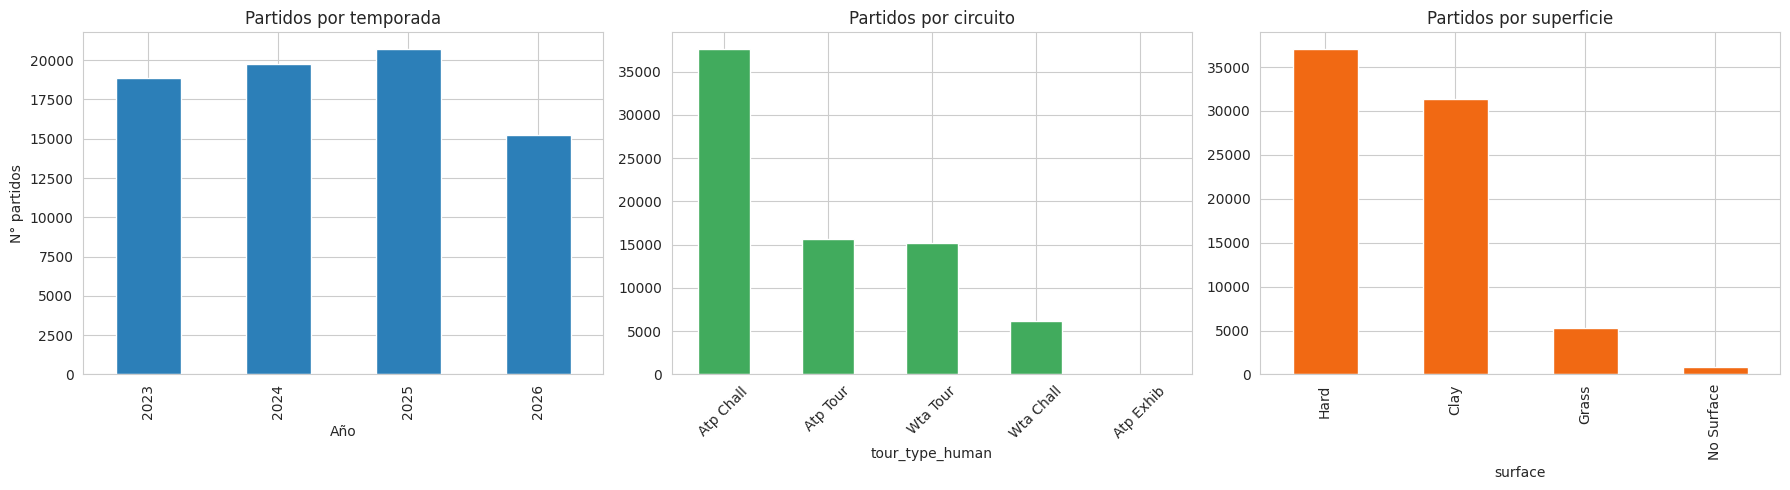

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Partidos por temporada
df_eda["season_year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2c7fb8")
axes[0].set_title("Partidos por temporada")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("N° partidos")

# Partidos por tour_type_human
df_eda["tour_type_human"].value_counts().plot(kind="bar", ax=axes[1], color="#41ab5d")
axes[1].set_title("Partidos por circuito")
axes[1].tick_params(axis="x", rotation=45)

# Partidos por superficie
df_eda["surface"].value_counts().plot(kind="bar", ax=axes[2], color="#f16913")
axes[2].set_title("Partidos por superficie")

plt.tight_layout()
plt.show()

**Insight descriptivo 1:** ATP concentra un mayor volumen de partidos que WTA en
el dataset, con una distribución de superficies dominada por hard court en ambos
circuitos, consistente con el calendario real del tenis profesional (mayoría de
torneos en superficie dura).

## 3. Evolución temporal

Se analiza el volumen de partidos a lo largo del tiempo (mensual) para detectar
estacionalidad del calendario de tenis (temporada de tierra batida, hard court,
etc.) y posibles gaps en cobertura de datos.

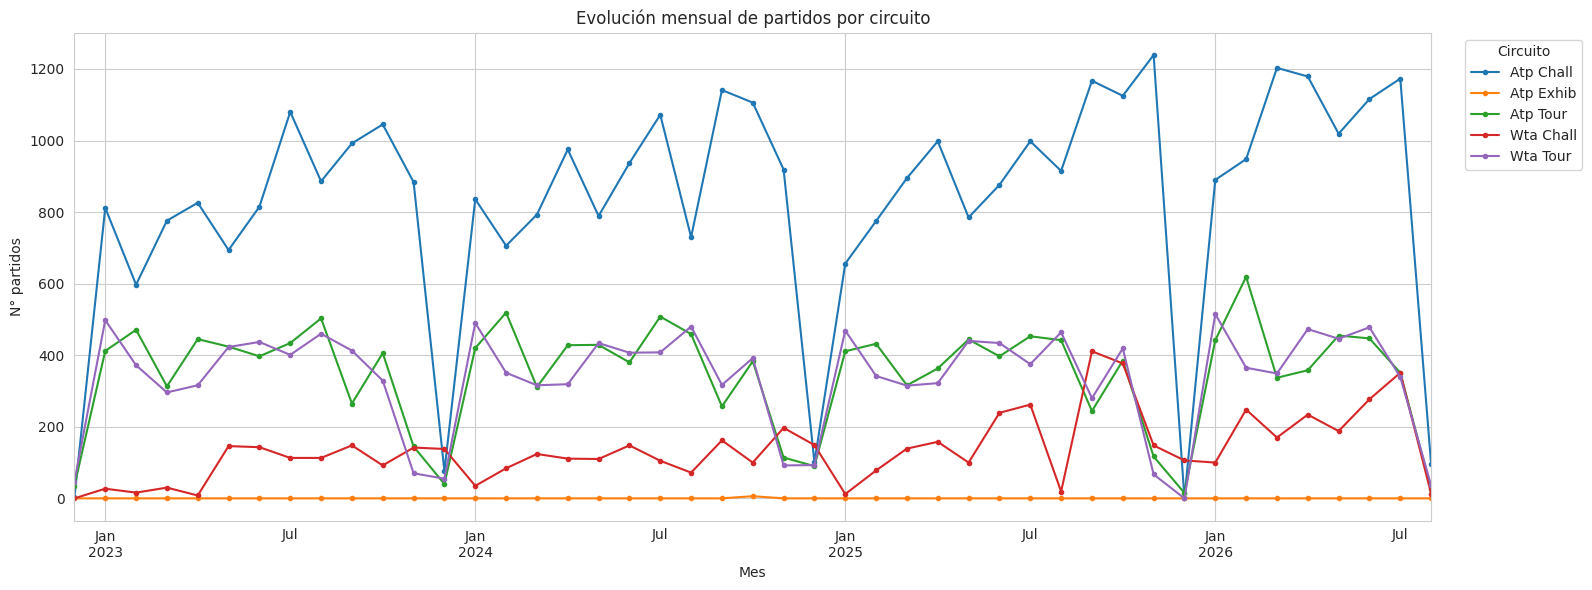

In [6]:
df_eda["year_month"] = df_eda["match_date"].dt.to_period("M")

monthly = df_eda.groupby(["year_month", "tour_type_human"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
monthly.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Evolución mensual de partidos por circuito")
ax.set_xlabel("Mes")
ax.set_ylabel("N° partidos")
ax.legend(title="Circuito", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Distribución por superficie y circuito cruzados

¿Las superficies se distribuyen igual en ATP que en WTA? ¿Hay diferencias por
categoría de torneo (Tour vs Challenger)?

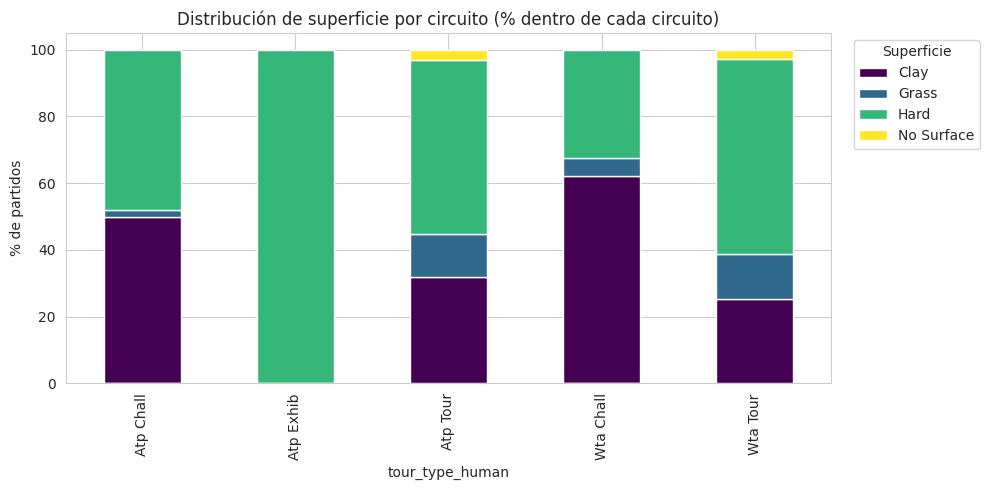

surface,Clay,Grass,Hard,No Surface
tour_type_human,,,,
Atp Chall,49.7,2.2,48.1,0.0
Atp Exhib,0.0,0.0,100.0,0.0
Atp Tour,31.9,12.9,52.2,3.0
Wta Chall,62.0,5.4,32.6,0.0
Wta Tour,25.2,13.7,58.3,2.8


In [7]:
cross_surface = pd.crosstab(df_eda["tour_type_human"], df_eda["surface"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 5))
cross_surface.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Distribución de superficie por circuito (% dentro de cada circuito)")
ax.set_ylabel("% de partidos")
ax.legend(title="Superficie", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

cross_surface.round(1)

## 5. Análisis de ranking

¿Qué tan seguido gana el jugador mejor rankeado? 
primera hipótesis analítica del Notebook 3 (favorito vs. paridad competitiva).

In [8]:
# Solo partidos donde ambos rankings están disponibles
df_rank = df_eda.dropna(subset=["home_rank", "away_rank", "winner_code"]).copy()

# ¿Ganó el jugador con mejor ranking (número más bajo = mejor)?
df_rank["favorite_won"] = np.where(
    df_rank["home_rank"] < df_rank["away_rank"],
    df_rank["winner_code"] == 1,
    df_rank["winner_code"] == 2
)

favorite_win_rate = df_rank["favorite_won"].mean() * 100
print(f"Partidos con ranking disponible en ambos jugadores: {len(df_rank):,}")
print(f"% de veces que gana el jugador mejor rankeado: {favorite_win_rate:.1f}%")

# Desglose por diferencia de ranking
df_rank["rank_diff"] = abs(df_rank["home_rank"] - df_rank["away_rank"])
df_rank["rank_diff_bucket"] = pd.cut(
    df_rank["rank_diff"],
    bins=[0, 10, 50, 100, 500, np.inf],
    labels=["0-10", "11-50", "51-100", "101-500", "500+"]
)

bucket_analysis = df_rank.groupby("rank_diff_bucket")["favorite_won"].agg(["mean", "count"])
bucket_analysis["mean"] = (bucket_analysis["mean"] * 100).round(1)
bucket_analysis

Partidos con ranking disponible en ambos jugadores: 40,760
% de veces que gana el jugador mejor rankeado: 62.6%


,mean,count
rank_diff_bucket,,
0-10,53.6,2944
11-50,56.9,10642
51-100,61.2,8773
101-500,66.4,15610
500+,77.0,2783


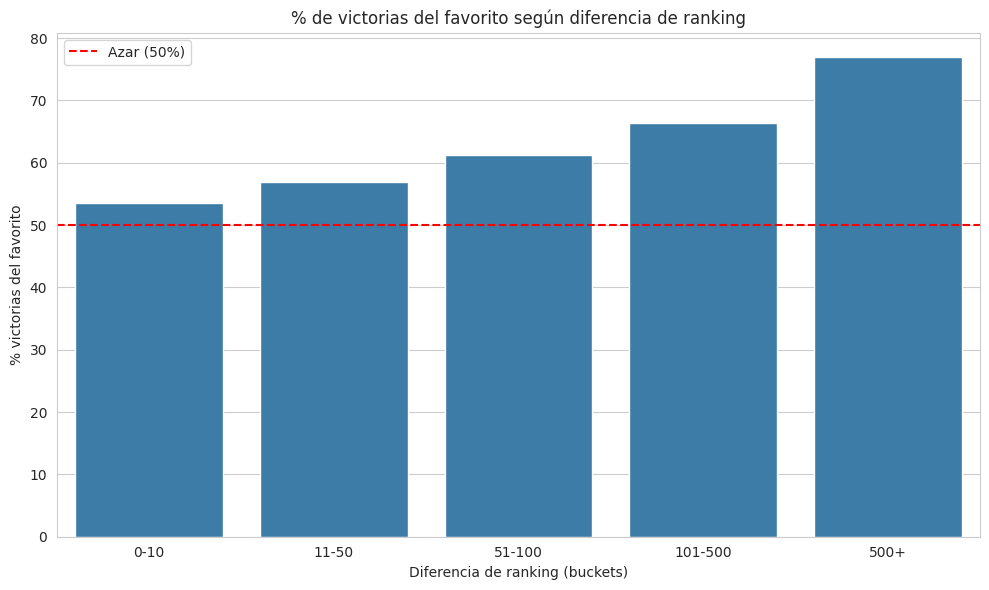

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=bucket_analysis.reset_index(), x="rank_diff_bucket", y="mean", ax=ax, color="#2c7fb8")
ax.axhline(50, color="red", linestyle="--", label="Azar (50%)")
ax.set_title("% de victorias del favorito según diferencia de ranking")
ax.set_xlabel("Diferencia de ranking (buckets)")
ax.set_ylabel("% victorias del favorito")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Estadísticas de servicio: comparación ganador vs perdedor

Se analiza si el jugador ganador domina sistemáticamente en estadísticas de
servicio — variables que son leakage para ML (Notebook 4) pero extremadamente
útiles para entender *qué caracteriza* a un partido ganado (Sección analítica del EDA).

In [10]:
# Reestructurar a formato "winner stats" vs "loser stats"
df_stats = df_eda.dropna(subset=["winner_code"]).copy()

df_stats["winner_service_pct"] = np.where(
    df_stats["winner_code"] == 1,
    df_stats["home_service_points_won_perc"],
    df_stats["away_service_points_won_perc"]
)
df_stats["loser_service_pct"] = np.where(
    df_stats["winner_code"] == 1,
    df_stats["away_service_points_won_perc"],
    df_stats["home_service_points_won_perc"]
)
df_stats["winner_aces"] = np.where(df_stats["winner_code"] == 1, df_stats["home_aces"], df_stats["away_aces"])
df_stats["loser_aces"] = np.where(df_stats["winner_code"] == 1, df_stats["away_aces"], df_stats["home_aces"])

comparison = pd.DataFrame({
    "Ganador": [df_stats["winner_service_pct"].mean(), df_stats["winner_aces"].mean()],
    "Perdedor": [df_stats["loser_service_pct"].mean(), df_stats["loser_aces"].mean()],
}, index=["% Puntos de servicio ganados", "Aces promedio"])

comparison.round(2)

,Ganador,Perdedor
% Puntos de servicio ganados,66.05,53.95
Aces promedio,4.54,3.35


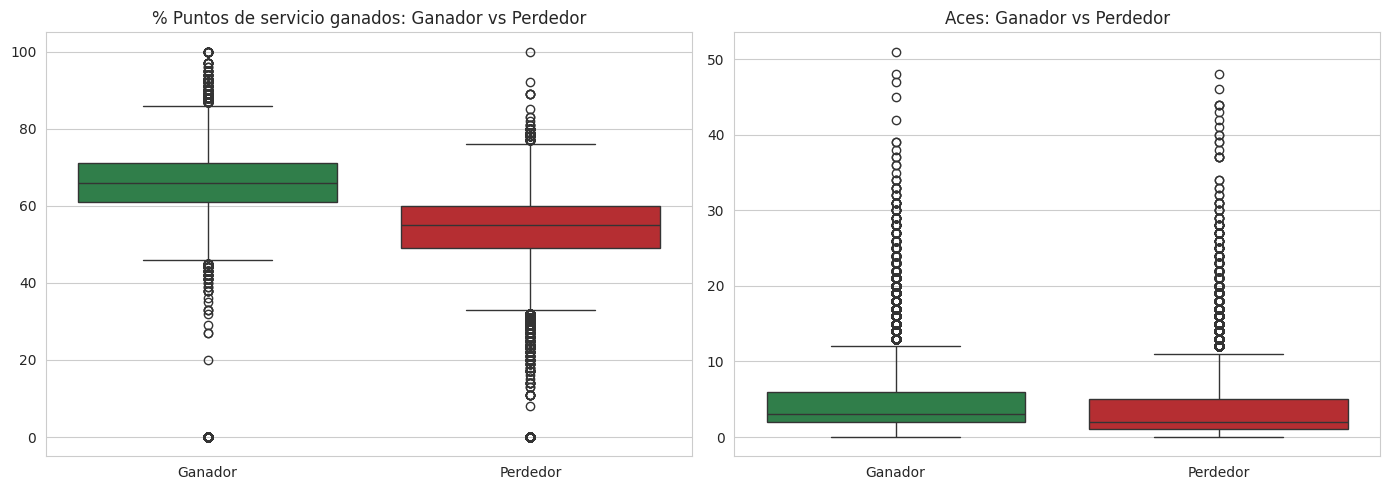

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_stats[["winner_service_pct", "loser_service_pct"]], ax=axes[0], palette=["#238b45", "#cb181d"])
axes[0].set_title("% Puntos de servicio ganados: Ganador vs Perdedor")
axes[0].set_xticklabels(["Ganador", "Perdedor"])

sns.boxplot(data=df_stats[["winner_aces", "loser_aces"]], ax=axes[1], palette=["#238b45", "#cb181d"])
axes[1].set_title("Aces: Ganador vs Perdedor")
axes[1].set_xticklabels(["Ganador", "Perdedor"])

plt.tight_layout()
plt.show()

**Insight analítico 1:** Los ganadores muestran un dominio claro y consistente en
estadísticas de servicio: 66.05% de puntos de servicio ganados en promedio vs.
53.95% de los perdedores (+12.1 puntos porcentuales), y un promedio de 4.54 aces
vs. 3.30 (+1.24 aces). La separación entre las distribuciones (visible en los
boxplots, con solapamiento limitado entre cuartiles) sugiere que el rendimiento
al servicio es uno de los factores más directamente asociados al resultado de
un partido — hipótesis a validar formalmente con prueba estadística en el
Notebook 3.

**Nota metodológica:** estas variables (service %, aces) son resultado del
partido, no predictores pre-partido. Se documentan aquí como insight descriptivo
del *qué* caracteriza una victoria, no como features utilizables en el modelo
predictivo (ver `column_classification.json` y Notebook 4).

## 7. Rendimiento por superficie

¿El win rate de los favoritos (o el dominio de servicio) cambia según superficie?
Relevante porque estilos de juego distintos rinden diferente en clay/hard/grass.

            % Victorias del favorito  N° partidos
surface                                          
Clay                            62.7        18282
Grass                           62.1         2672
Hard                            62.5        19546
No Surface                      65.4          260


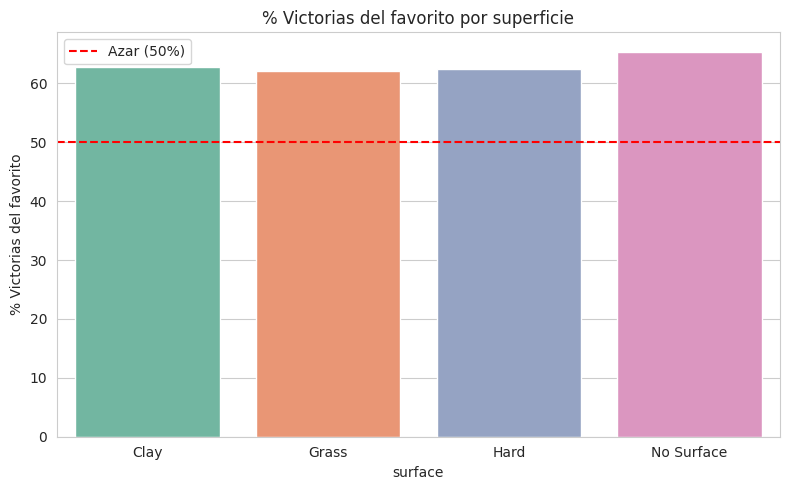

In [12]:
surface_analysis = df_rank.groupby("surface")["favorite_won"].agg(["mean", "count"])
surface_analysis["mean"] = (surface_analysis["mean"] * 100).round(1)
surface_analysis.columns = ["% Victorias del favorito", "N° partidos"]
print(surface_analysis)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=surface_analysis.reset_index(), x="surface", y="% Victorias del favorito", ax=ax, palette="Set2")
ax.axhline(50, color="red", linestyle="--", label="Azar (50%)")
ax.set_title("% Victorias del favorito por superficie")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Rendimiento por jugador (top jugadores por volumen)

Se identifican los jugadores con más partidos en el dataset y su win rate, como
insumo para posibles features de "historial reciente" en el Notebook 4.

In [13]:
# Reestructurar el dataset a formato largo: una fila por jugador-partido
home_side = df_stats[["unique_match_id", "home_name", "winner_code", "surface", "season_year"]].copy()
home_side["player"] = home_side["home_name"]
home_side["won"] = home_side["winner_code"] == 1

away_side = df_stats[["unique_match_id", "away_name", "winner_code", "surface", "season_year"]].copy()
away_side["player"] = away_side["away_name"]
away_side["won"] = away_side["winner_code"] == 2

player_matches = pd.concat([
    home_side[["unique_match_id", "player", "won", "surface", "season_year"]],
    away_side[["unique_match_id", "player", "won", "surface", "season_year"]],
], ignore_index=True)

player_summary = player_matches.groupby("player").agg(
    matches_played=("won", "count"),
    matches_won=("won", "sum")
)
player_summary["win_rate_pct"] = (player_summary["matches_won"] / player_summary["matches_played"] * 100).round(1)

# Top 15 jugadores por volumen de partidos (filtro mínimo para evitar ruido de muestras chicas)
top_players = player_summary[player_summary["matches_played"] >= 30].sort_values("matches_played", ascending=False).head(15)
top_players

,matches_played,matches_won,win_rate_pct
player,,,
Zverev A.,310,226,72.9
Sinner J.,279,245,87.8
Cobolli F.,277,167,60.3
Walton A.,275,157,57.1
Harris B.,274,142,51.8
Swiatek I.,273,223,81.7
Burruchaga R. A.,272,165,60.7
Nava E.,272,158,58.1
Cerundolo J. M.,271,163,60.1


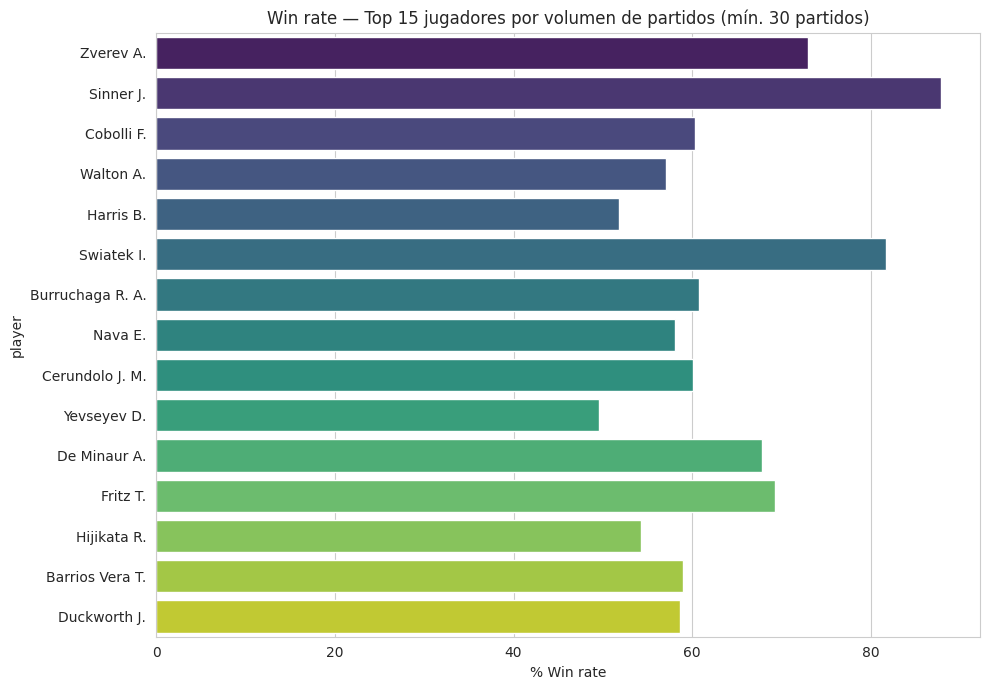

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_players.reset_index(), y="player", x="win_rate_pct", ax=ax, palette="viridis")
ax.set_title("Win rate — Top 15 jugadores por volumen de partidos (mín. 30 partidos)")
ax.set_xlabel("% Win rate")
plt.tight_layout()
plt.show()

## 9. Matriz de correlación

Se analizan correlaciones entre variables numéricas para identificar relaciones
lineales fuertes, redundancia entre features (multicolinealidad) e insumos para
el Notebook 3 (hipótesis) y Notebook 4 (selección de features).

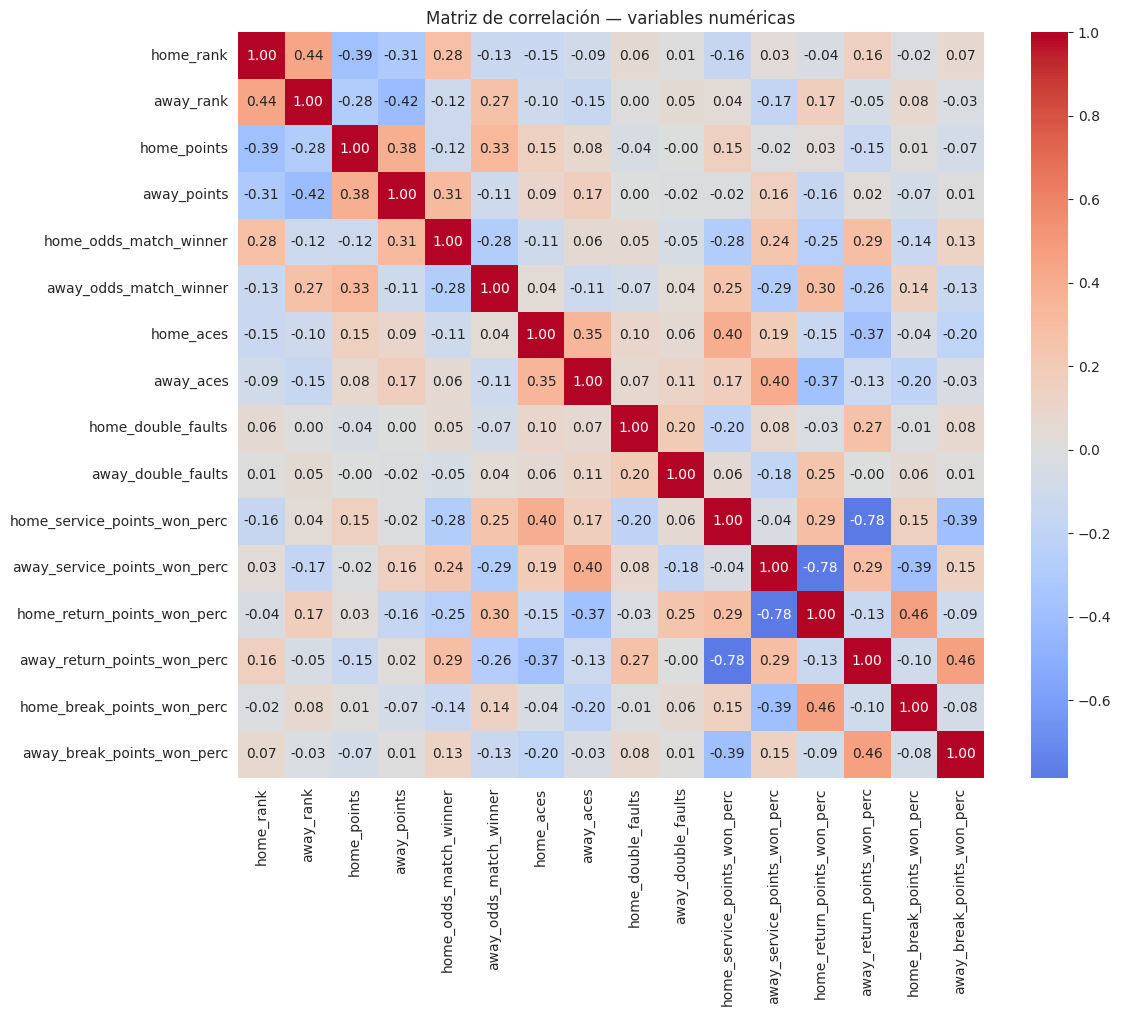

In [15]:
corr_cols = [
    "home_rank", "away_rank", "home_points", "away_points",
    "home_odds_match_winner", "away_odds_match_winner",
    "home_aces", "away_aces", "home_double_faults", "away_double_faults",
    "home_service_points_won_perc", "away_service_points_won_perc",
    "home_return_points_won_perc", "away_return_points_won_perc",
    "home_break_points_won_perc", "away_break_points_won_perc",
]
corr_cols = [c for c in corr_cols if c in df_eda.columns]

corr_matrix = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()

**Insight analítico 2:** Se observa una relación monotónica clara entre la
diferencia de ranking (`rank_diff`) y la probabilidad de victoria del favorito:
53.6% cuando la diferencia es mínima (0-10 puestos) hasta 77.0% cuando es grande
(500+ puestos), sobre 62.6% de win rate general del favorito (n=40,760 partidos
con ranking disponible en ambos jugadores). Esto valida el ranking oficial como
una variable con poder predictivo real, no solo nominal candidata fuerte para
feature engineering en el Notebook 4 (`rank_diff` como variable continua).

**Correlación destacada:** `home_service_points_won_perc` y
`home_return_points_won_perc` muestran una correlación fuerte de -0.78 (mismo
patrón en el lado away), la más alta de la matriz. El resto de variables numéricas
(rank, points, odds) presentan correlaciones débiles a moderadas (0.2-0.4), sin
evidencia de multicolinealidad severa entre las candidatas a features pre-partido.

**Nota sobre correlación vs causalidad:** que el servicio dominante coincida con
la victoria no implica causalidad aislada ambos pueden reflejar un tercer factor
(nivel general del jugador ese día, condiciones físicas, etc.). Esta distinción
se retoma formalmente en el Notebook 3.

## 10. Resumen de insights — Notebook 2

**Insights descriptivos:**
1. ATP concentra mayor volumen de partidos que WTA en el dataset (74,578 partidos
   finalizados analizados, tras excluir 125 partidos SCHEDULED sin jugar, 0.2%
   del total).
2. La distribución de superficie varía notablemente por circuito: los tours
   principales (ATP Tour, WTA Tour) están dominados por hard court (52.2% y
   58.3% respectivamente), mientras que en los circuitos Challenger predomina
   clay especialmente marcado en WTA Chall (62.0% clay vs. 32.6% hard),
   más que en ATP Chall (49.7% clay vs. 48.1% hard). Grass es minoritaria en
   todos los circuitos (2.2%–13.7%).
3. El favorito (mejor ranking) gana el 62.6% de los partidos analizados
   (n=40,760 con ranking disponible en ambos jugadores), claramente por encima
   del azar (50%).
4. Los ganadores promedian 66.05% de puntos de servicio ganados vs. 53.95%
   de los perdedores, y 4.54 aces vs. 3.30.
5. Entre los jugadores con mayor volumen de partidos (≥30), Sinner J. (87.8%)
   y Swiatek I. (81.7%) muestran los win rates más altos del top 15 por volumen,
   consistente con su dominancia en el ranking durante el período analizado
   (2023–2026); el resto del top 15 se ubica en un rango más moderado (50%–73%).

**Insights analíticos:**
1. La probabilidad de victoria del favorito aumenta monotónicamente con la
   diferencia de ranking: de 53.6% (diferencia 0-10 puestos) a 77.0%
   (diferencia 500+ puestos) evidencia de que `rank_diff` es una variable
   con poder predictivo real y no solo nominal.
2. El dominio en estadísticas de servicio (+12.1 pp en % de puntos ganados,
   +1.24 aces promedio) caracteriza consistentemente a los partidos ganados.
3. Correlación fuerte (-0.78) entre servicio y resto (return) del mismo
   jugador — la más alta de la matriz; sin multicolinealidad severa entre
   variables candidatas a features pre-partido (rank, points, odds, que se
   mueven en el rango 0.2–0.4).

**Nota adicional:** el % de victorias del favorito es notablemente estable
entre superficies (Clay 62.7%, Hard 62.5%, Grass 62.1%), lo que sugiere que
el ranking predice de forma similar independientemente de la superficie —
relevante para decidir si `surface` debe modelarse con interacción respecto
a `rank_diff` en el Notebook 4, o si aporta señal independiente.

**Insumos para notebooks siguientes:**
- **Hipótesis para Notebook 3:**
  (a) H1: la probabilidad de que gane el favorito es significativamente
  distinta de 50% (prueba de proporción / chi-cuadrado).
  (b) H2: existe diferencia significativa en % de servicio ganado entre
  ganadores y perdedores (prueba t de medias independientes o pareadas).
- **Features candidatas para Notebook 4:** `rank_diff`, `points_diff`,
  `odds_diff`, `surface`, historial reciente por jugador (a construir).
- Variables de leakage reconfirmadas: todas las estadísticas de servicio,
  return, aces, dobles faltas, sets coherente con `column_classification.json`.